# 01 — Tren Recall@k per Metode (Top-1 s/d Top-10)

**Pertanyaan yang dijawab:** Seberapa cepat setiap metode chunking menemukan chunk relevan seiring k bertambah?

**Cara baca:** Recall@k mengukur proporsi chunk relevan yang berhasil ditemukan dari semua chunk relevan yang ada. Makin tinggi = makin banyak bukti relevan yang di-retrieve.

> **Prasyarat:** Jalankan `00_load_data.ipynb` terlebih dahulu.

## 1. Import & Load Cache

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PKL_DIR = Path("_cache")

with open(PKL_DIR / "data_eval.pkl", "rb") as f:
    cache = pickle.load(f)

all_df  = cache["all_df"]
FIG_DIR = cache["FIG_DIR"]

print(f"Data loaded: {all_df.shape[0]} rows")
print(f"Output ke  : {FIG_DIR.resolve()}")

Data loaded: 900 rows
Output ke  : D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\figures


## 2. Konstanta Visual

In [2]:
METHOD_ORDER  = ["Element-Based", "MaxMin Semantic", "Recursive"]
METHOD_COLORS = {
    "Element-Based":   "#2196F3",
    "MaxMin Semantic": "#FF9800",
    "Recursive":       "#4CAF50",
}
METHOD_MARKERS = {
    "Element-Based":   "o",
    "MaxMin Semantic": "s",
    "Recursive":       "^",
}

plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
})
print("Konstanta siap.")

Konstanta siap.


## 3. Hitung Rata-rata Recall@k per Top-k per Metode

In [3]:
trend = (
    all_df
    .groupby(["top_k", "method"])["recall_at_k"]
    .mean()
    .reset_index()
    .rename(columns={"recall_at_k": "mean_recall"})
)

# Preview tabel
trend.pivot(index="top_k", columns="method", values="mean_recall").round(4)

method,Element-Based,MaxMin Semantic,Recursive
top_k,,,
1,0.1994,0.1264,0.1488
2,0.2440,0.2672,0.2603
3,0.2976,0.3190,0.2603
4,0.3744,0.3948,0.3293
5,0.3923,0.4466,0.3523
6,0.4518,0.4925,0.4138
7,0.4696,0.4925,0.4207
8,0.5173,0.5098,0.4207
9,0.5173,0.5270,0.4207


## 4. Plot

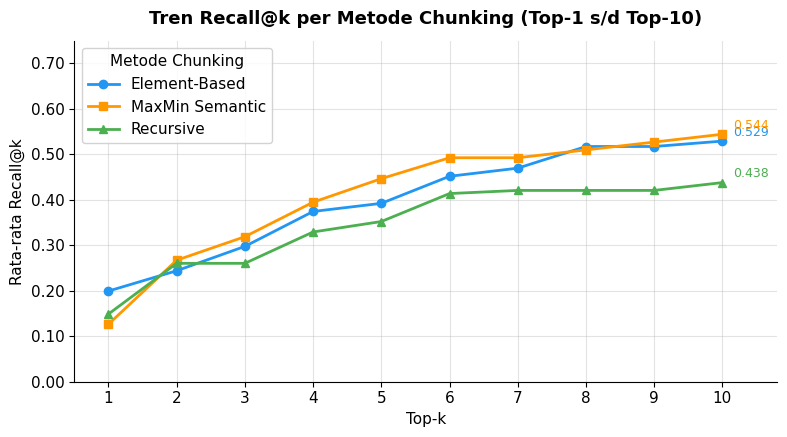

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for method in METHOD_ORDER:
    d = trend[trend["method"] == method].sort_values("top_k")
    ax.plot(
        d["top_k"], d["mean_recall"],
        color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method],
        linewidth=2, markersize=6,
        label=method,
    )
    # Anotasi titik terakhir (top-10)
    last = d[d["top_k"] == 10].iloc[0]
    ax.annotate(
        f"{last['mean_recall']:.3f}",
        xy=(10, last["mean_recall"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=9, color=METHOD_COLORS[method],
    )

ax.set_xlabel("Top-k")
ax.set_ylabel("Rata-rata Recall@k")
ax.set_title(
    "Tren Recall@k per Metode Chunking (Top-1 s/d Top-10)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.8)
ax.set_ylim(0, 0.75)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(title="Metode Chunking", framealpha=0.85)

fig.tight_layout()
plt.show()

## 5. Simpan PNG

In [5]:
out_path = FIG_DIR / "01_recall_trend.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Tersimpan: {out_path.resolve()}")

Tersimpan: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\figures\01_recall_trend.png

## 6. Interpretasi

- **MaxMin Semantic & Element-Based** recall terus naik signifikan seiring k (0.13 → 0.54), artinya chunk relevan sering ada di ranking menengah-atas.
- **Recursive** recall-nya lebih rendah di top-10, tapi MRR-nya lebih tinggi (lihat notebook `02`) — artinya Recursive lebih sering menempatkan chunk relevan di posisi teratas.
- Perbedaan antar metode mulai menyempit di k≥8.